# Measurable NFR Values: Initial vs Tested

This notebook shows charts based on numeric values (initial value vs tested value), not compliance scores.

In [1]:
# Bootstrap for Jupyter runtime: auto-install matplotlib if missing
import sys
import subprocess

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt

print("matplotlib is ready")

matplotlib is ready


In [2]:
# Initial vs tested numeric values (latest validated performance evidence)
# Source: k6/out/nfr-validated-report.json
nfr_data = [
    {
        "requirement": "patient_record_latency",
        "metric": "patient_record p80 proxy",
        "target_text": "<= 5000 ms",
        "unit": "ms",
        "initial_value": 384.3019,
        "tested_value": 4675.26826,
    },
    {
        "requirement": "appointment_write_latency",
        "metric": "appointment_write p75 proxy",
        "target_text": "<= 7000 ms",
        "unit": "ms",
        "initial_value": 414.4959,
        "tested_value": 5246.03224,
    },
    {
        "requirement": "appointment_write_samples",
        "metric": "appointment_write_samples",
        "target_text": ">= 100",
        "unit": "count",
        "initial_value": 258,
        "tested_value": 2293,
    },
    {
        "requirement": "http_req_failed_rate",
        "metric": "http_req_failed",
        "target_text": "< 1%",
        "unit": "rate",
        "initial_value": 0.0,
        "tested_value": 0.0,
    },
]

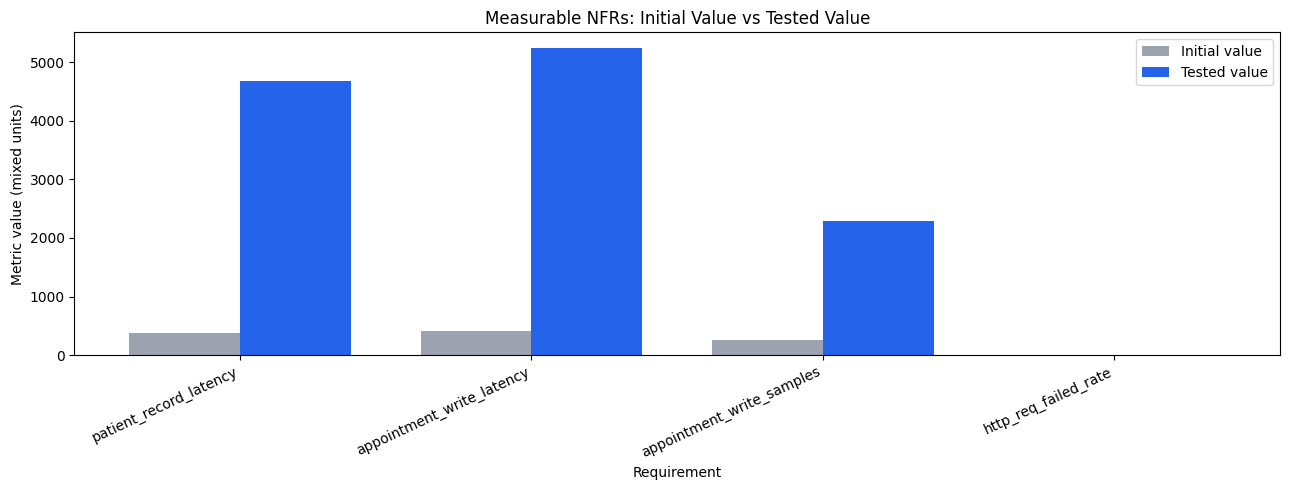

In [3]:
# Overall chart: initial value vs tested value
requirements = [x["requirement"] for x in nfr_data]
initial_values = [x["initial_value"] for x in nfr_data]
tested_values = [x["tested_value"] for x in nfr_data]

x = list(range(len(requirements)))
bar_w = 0.38

plt.figure(figsize=(13, 5))
plt.bar([i - bar_w/2 for i in x], initial_values, width=bar_w, label="Initial value", color="#9CA3AF")
plt.bar([i + bar_w/2 for i in x], tested_values, width=bar_w, label="Tested value", color="#2563EB")
plt.xticks(x, requirements, rotation=25, ha="right")
plt.title("Measurable NFRs: Initial Value vs Tested Value")
plt.xlabel("Requirement")
plt.ylabel("Metric value (mixed units)")
plt.legend()
plt.tight_layout()
plt.show()

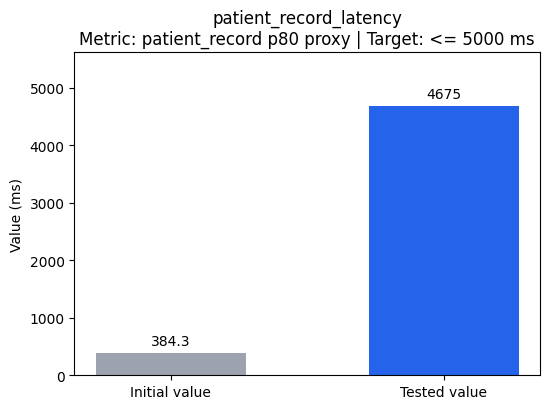

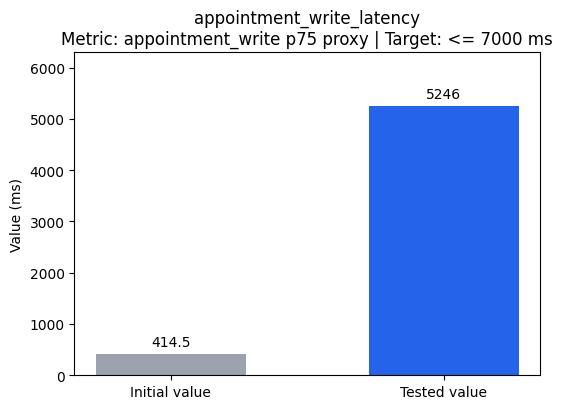

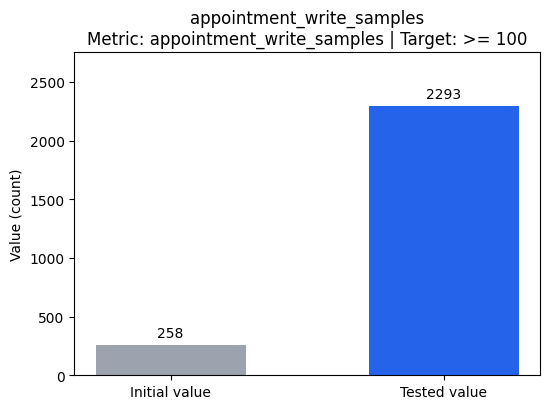

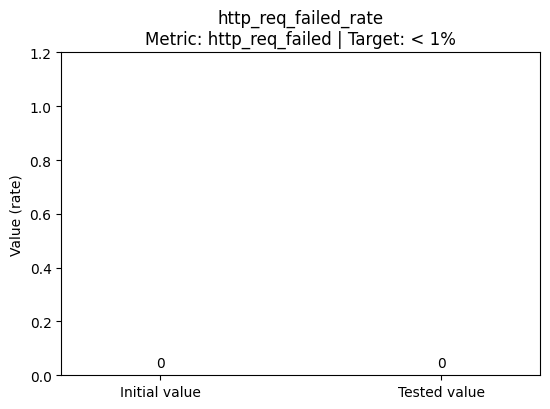

In [4]:
# Separate chart per requirement: initial value vs tested value
for item in nfr_data:
    labels = ["Initial value", "Tested value"]
    values = [item["initial_value"], item["tested_value"]]
    colors = ["#9CA3AF", "#2563EB"]

    plt.figure(figsize=(5.6, 4.2))
    bars = plt.bar(labels, values, color=colors, width=0.55)
    plt.title(
        f"{item['requirement']}\n"
        f"Metric: {item['metric']} | Target: {item['target_text']}"
    )
    plt.ylabel(f"Value ({item['unit']})")

    max_val = max(values) if max(values) > 0 else 1
    plt.ylim(0, max_val * 1.2)

    for b, v in zip(bars, values):
        plt.text(b.get_x() + b.get_width()/2, v + max_val * 0.03, f"{v:.4g}", ha="center")

    plt.tight_layout()
    plt.show()